In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_excel("Taylor_Swift_Genius_Data.xlsx",header=0)
data['Album'] = data['Album'].astype(str)
data['Song Name'] = data['Song Name'].astype(str)

In [ ]:
def convertir_duracion(tiempo):
    minuto = tiempo//60
    segundos = tiempo%60
    segundos = round(segundos,1)
    return str(minuto)+"m "+str(segundos)+ "s"

In [ ]:
data.head()

,Track Number,Album,Taylor's Version,Song Name,Duration (s),From The Vault
0,10,Taylor Swift,No,Mary's Song (Oh My My My),213,NaN
1,14,Taylor Swift,No,A Perfectly Good Heart,220,NaN
2,1,Taylor Swift,No,Tim McGraw,232,NaN
3,3,Taylor Swift,No,Teardrops On My Guitar,203,NaN
4,5,Taylor Swift,No,Cold as You,239,NaN


### Duration Analysis

In [ ]:
sorted_column = data.sort_values(['Duration (s)'], ascending = False)
sorted_column.head()
sorted_column.tail()

,Track Number,Album,Taylor's Version,Song Name,Duration (s),From The Vault
129,17,Lover,No,It's Nice to Have a Friend,150,NaN
243,9,The Life of a Showgirl,No,Wood,150,NaN
198,18,Midnights,No,Glitch,148,NaN
110,19,1989,Yes,Now That We Don't Talk,146,Yes
228,25,The Tortured Poets Department,No,I Look in People's Windows,131,NaN


In [ ]:
max_tiempo = data["Duration (s)"].max()
min_tiempo = data["Duration (s)"].min()

In [ ]:
print("Canción de mayor duración:",data.loc[data['Duration (s)'].idxmax(), 'Song Name'])
print(convertir_duracion(max_tiempo))
print("Canción de menor duración:",data.loc[data['Duration (s)'].idxmin(), 'Song Name'])
print(convertir_duracion(min_tiempo))
print("Tiempo promedio de canciones")
print(convertir_duracion(data["Duration (s)"].mean()))

Canción de mayor duración: All Too Well (10 Minute Version)
10m 13s
Canción de menor duración: I Look in People's Windows
2m 11s
Tiempo promedio de canciones
3.0m 56.0s


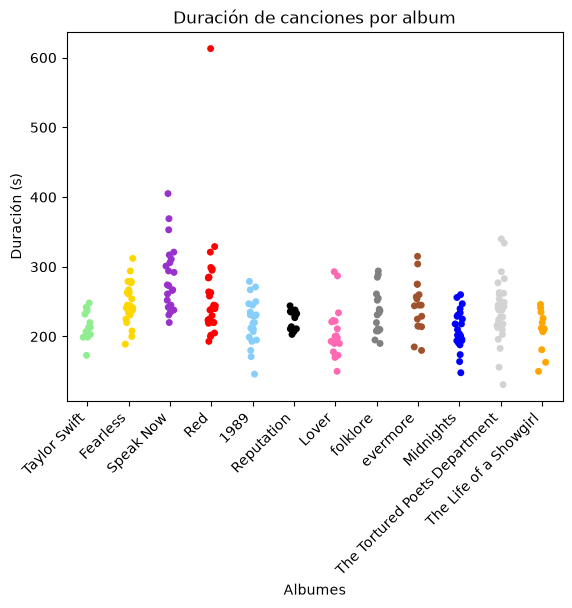

In [ ]:
sns.stripplot(data=data,x='Album',y='Duration (s)',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("Duración (s)")
plt.xlabel("Albumes")
plt.title("Duración de canciones por album")
plt.show()

Album
1989                             4868
Fearless                         6422
Lover                            3705
Midnights                        4824
Red                              7826
Reputation                       3338
Speak Now                        6273
Taylor Swift                     3027
The Life of a Showgirl           2500
The Tortured Poets Department    7341
evermore                         4137
folklore                         4019
Name: Duration (s), dtype: int64


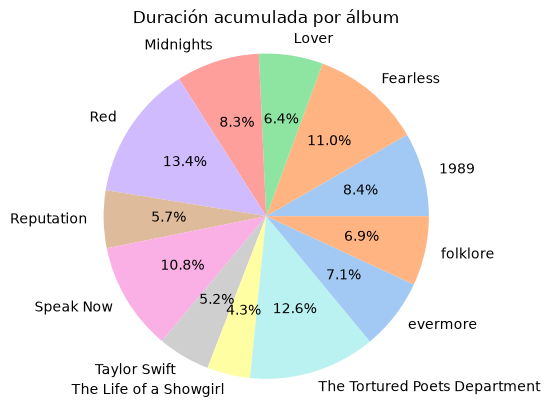

In [ ]:
album_duration = data.groupby("Album")["Duration (s)"].sum()
print(album_duration)
plt.pie(album_duration,labels=album_duration.index,colors= sns.color_palette('pastel'),autopct='%1.1f%%',radius=1.1)
plt.title("Duración acumulada por álbum")
plt.show()

In [ ]:
album_mayor = album_duration.idxmax()
album_menor = album_duration.idxmin()
album_songs = data.groupby("Album").size()
print("Album de mayor duración:",album_mayor)
print(convertir_duracion(album_duration[album_mayor]))
print("Número de canciones: ",album_songs[album_mayor])
print("Album de menor duración: ",album_menor)
print(convertir_duracion(album_duration[album_menor]))
print("Número de canciones: ",album_songs[album_menor])

Album de mayor duración: Red
130m 26s
Número de canciones:  30
Album de menor duración:  The Life of a Showgirl
41m 40s
Número de canciones:  12


Mostrar los tracks 5

In [ ]:
# Dos opciones para mostrar
print(data[data["Track Number"]==5][["Song Name","Album"]])
print(data.loc[data["Track Number"] == 5, ["Song Name", "Album"]])

                      Song Name                          Album
4                   Cold as You                   Taylor Swift
18                  White Horse                       Fearless
44                    Dear John                      Speak Now
66                 All Too Well                            Red
96   All You Had To Do Was Stay                           1989
118                    Delicate                     Reputation
146                  The Archer                          Lover
153           my tears ricochet                       folklore
174                 tolerate it                       evermore
188     You're On Your Own, Kid                      Midnights
208               So Long, Lond  The Tortured Poets Department
239             Eldest Daughter         The Life of a Showgirl


In [ ]:
print(data.loc[data["Track Number"] == 5, ["Song Name", "Album"]].to_string(index=False)) # Sin mostrar el índice

                 Song Name                         Album
               Cold as You                  Taylor Swift
               White Horse                      Fearless
                 Dear John                     Speak Now
              All Too Well                           Red
All You Had To Do Was Stay                          1989
                  Delicate                    Reputation
                The Archer                         Lover
         my tears ricochet                      folklore
               tolerate it                      evermore
   You're On Your Own, Kid                     Midnights
             So Long, Lond The Tortured Poets Department
           Eldest Daughter        The Life of a Showgirl


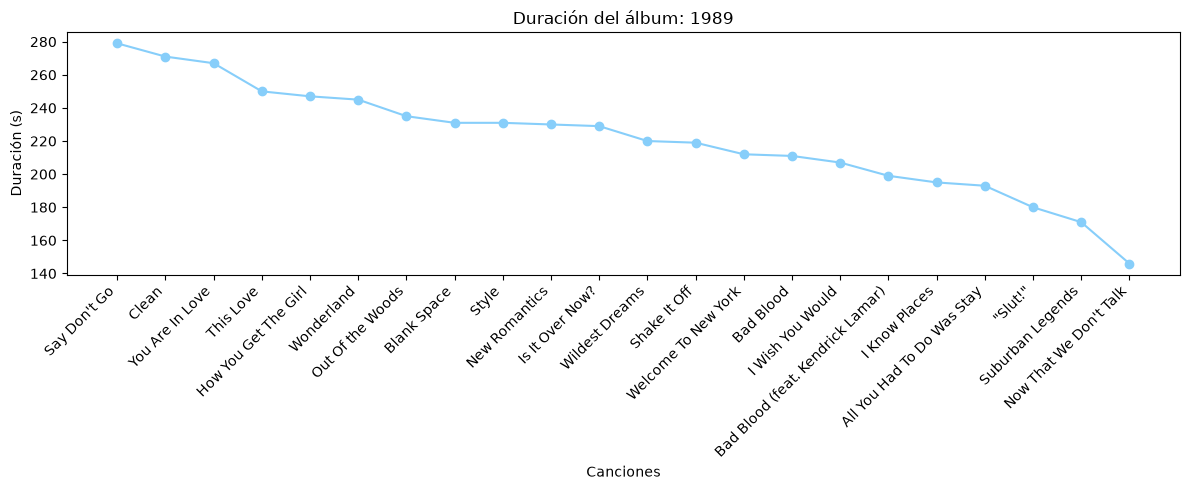

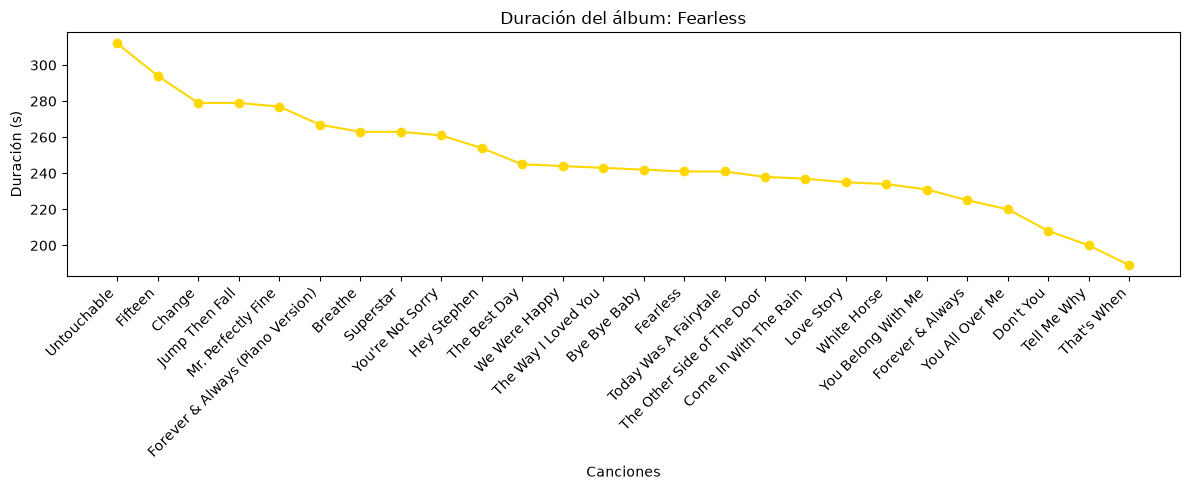

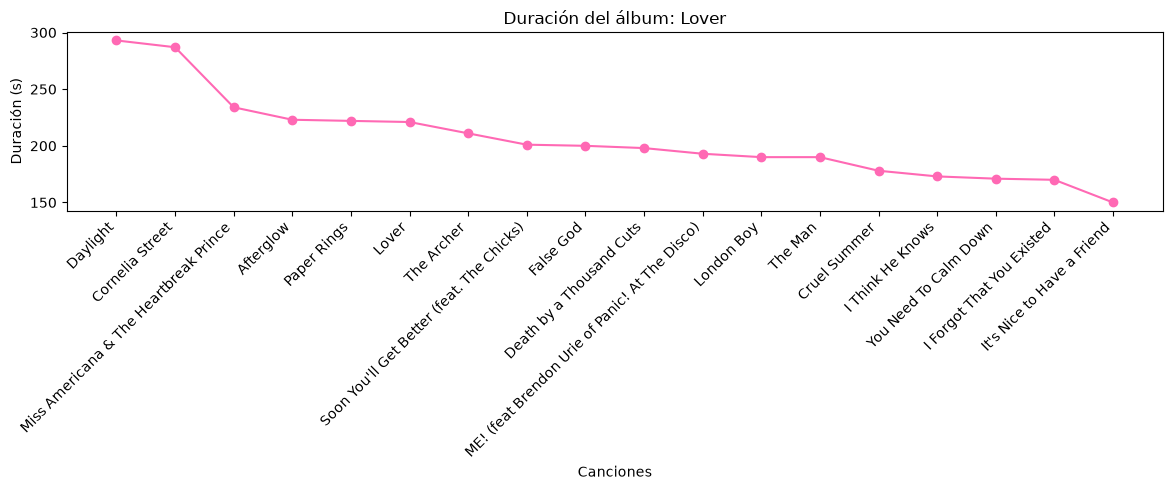

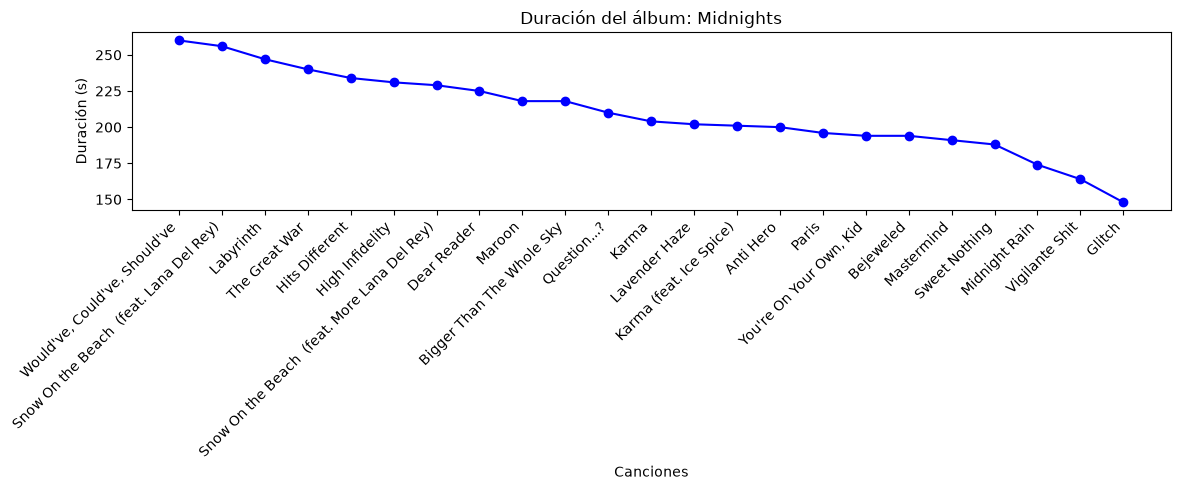

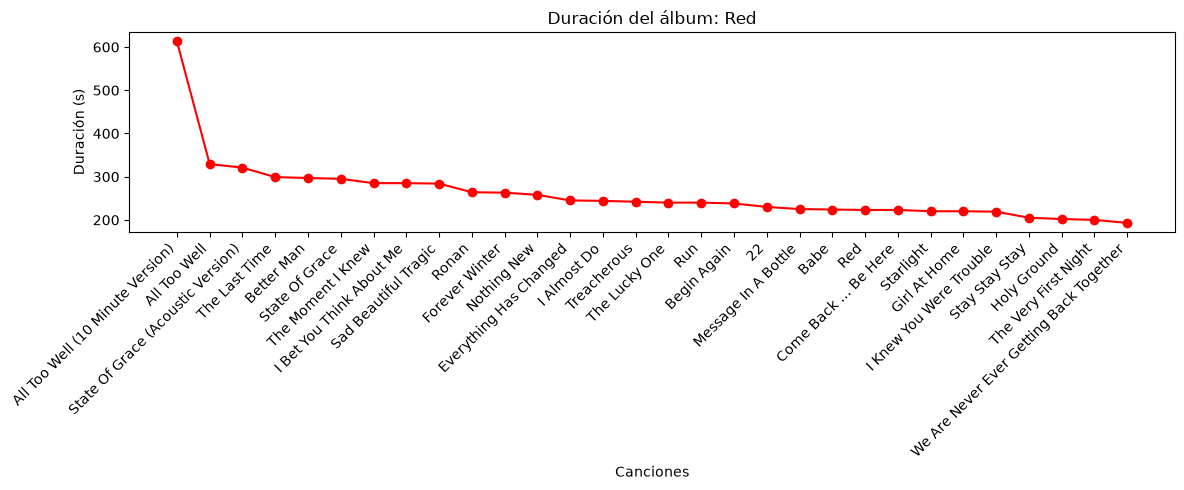

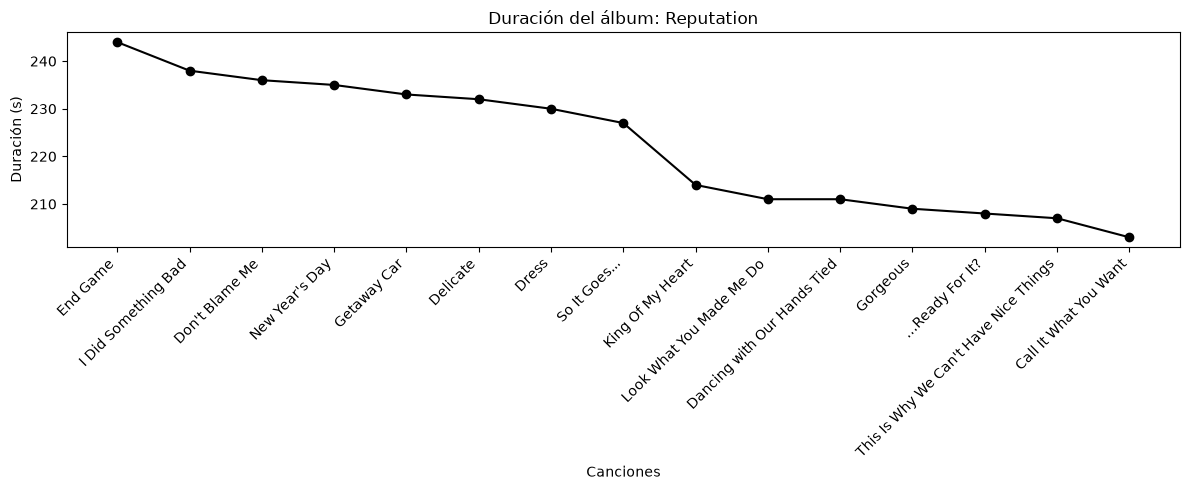

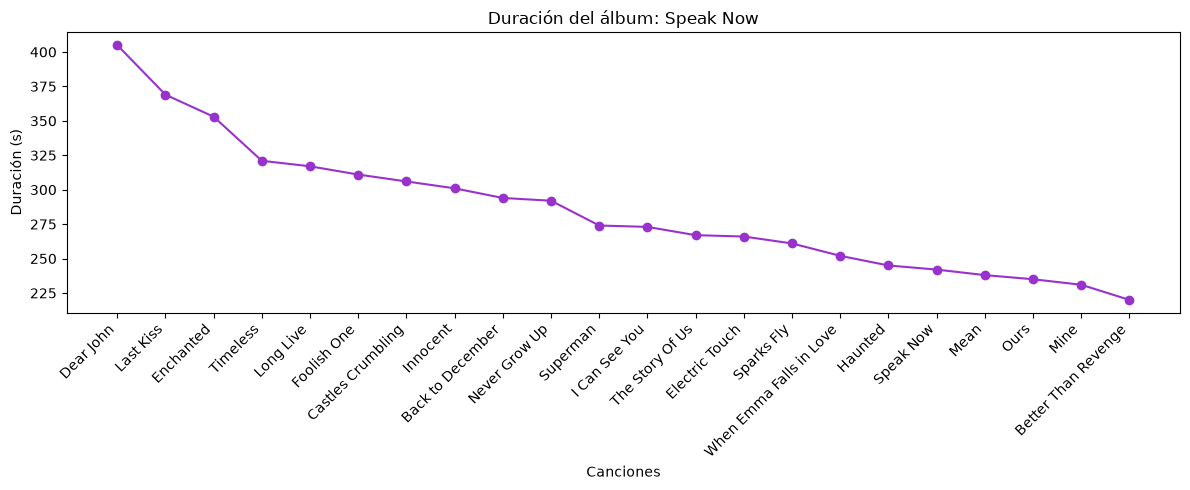

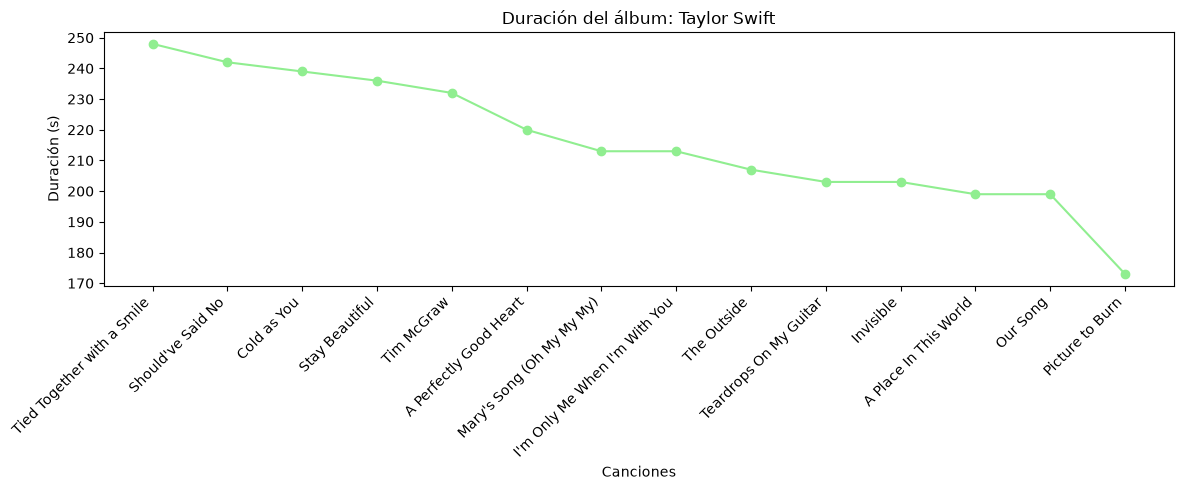

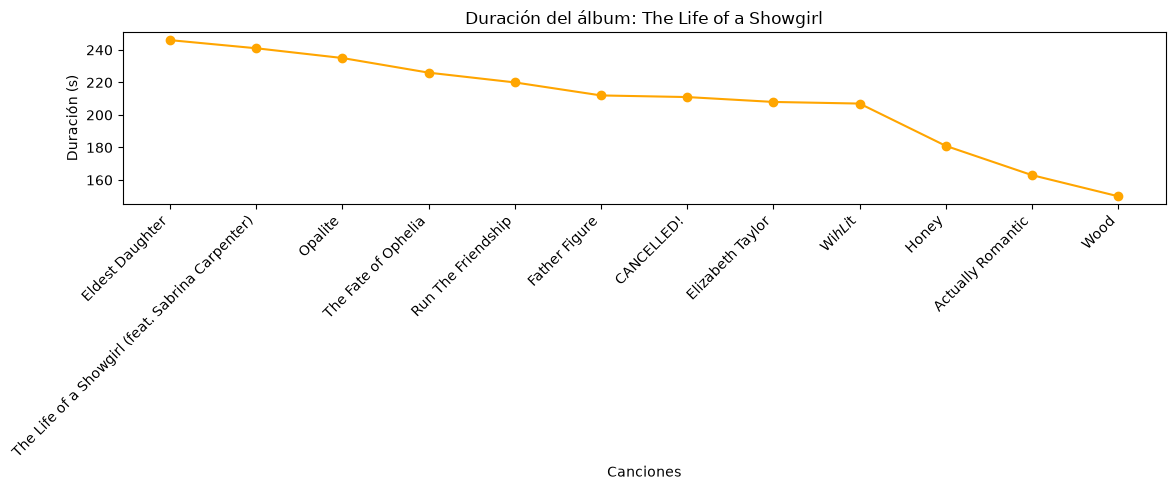

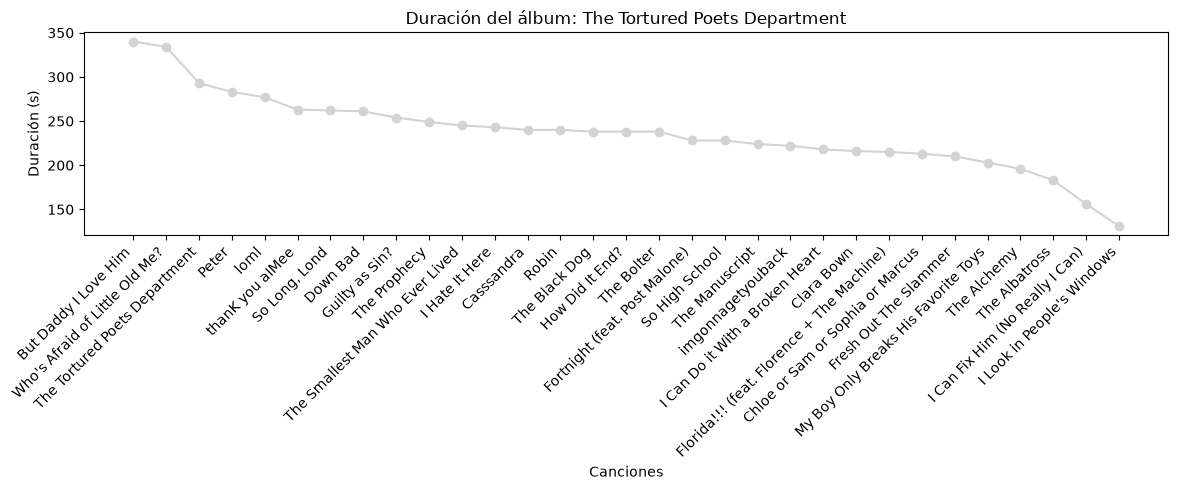

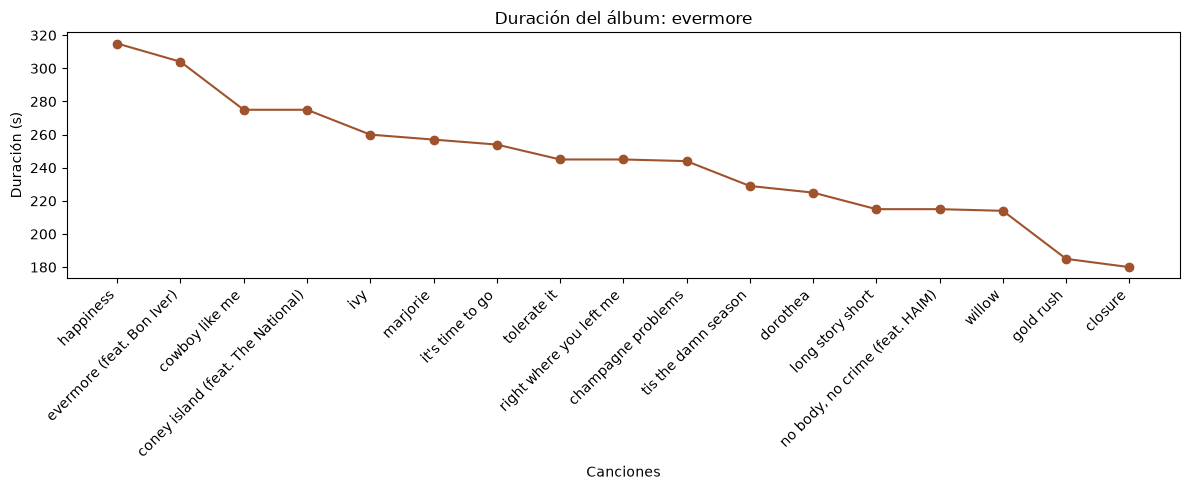

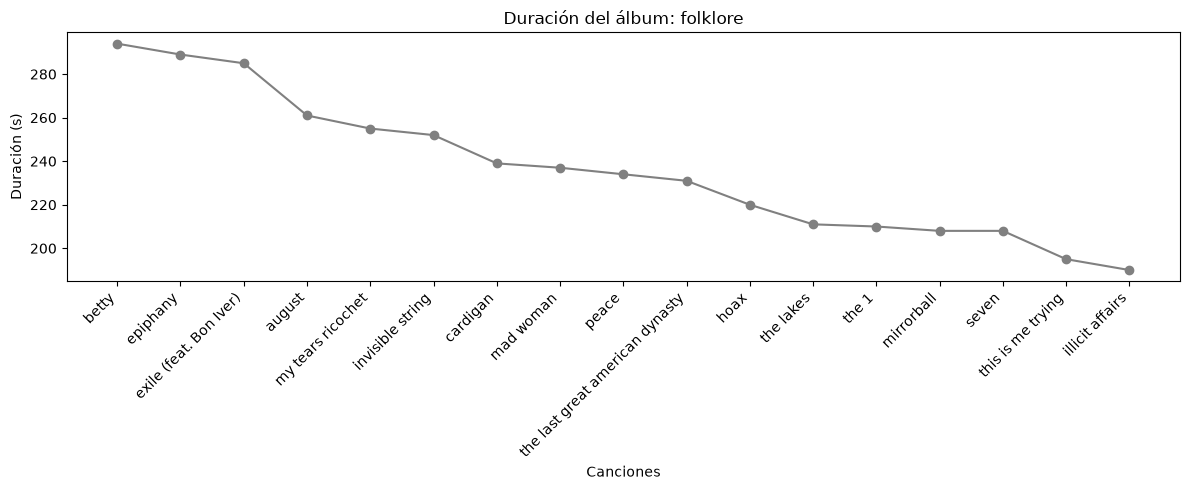

In [ ]:
sorted_column = data.sort_values(
    ['Album', 'Duration (s)'],
    ascending=[True, False]
)

album_colors = {
    'Taylor Swift': 'lightgreen',
    'Fearless': 'gold',
    'Speak Now': 'darkorchid',
    'Red': 'red',
    '1989': 'lightskyblue',
    'Reputation': 'black',
    'Lover': 'hotpink',
    'folklore': 'grey',
    'evermore': 'sienna',
    'Midnights': 'blue',
    'The Tortured Poets Department': 'lightgrey',
    'The Life of a Showgirl': 'orange'
}

for album, album_data in sorted_column.groupby('Album'):
    plt.figure(figsize=(12, 5))
    plt.plot(album_data['Song Name'],album_data['Duration (s)'],marker='o',color=album_colors[album])
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Canciones")
    plt.ylabel("Duración (s)")
    plt.title(f"Duración del álbum: {album}")
    plt.tight_layout()
    plt.show()

## Word Analysis

Vamos a partir con un analisis de cantidad de palabras en total, vamos a excluir los signos de puntuación.

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [ ]:
data = pd.read_excel("Taylor_Swift_Genius_Data.xlsx",header=0)
data['Album'] = data['Album'].astype(str)

data.head()
len(data)

247

In [ ]:
indices_to_drop = data[data['Lyrics'] == "-"].index
print(indices_to_drop)
data.drop(indices_to_drop, inplace=True)
len(data)

Index([29, 81, 113, 202, 203], dtype='int64')


242

In [ ]:
def palabras_unicas(texto):
    palabras = re.findall(r'\b[a-zA-ZÀ-ÿ]+\b', str(texto).lower())
    return set(palabras)

def palabras_totales(texto):
    palabras = re.findall(r'\b[a-zA-ZÀ-ÿ]+\b', str(texto).lower())
    return palabras

In [ ]:
data["Número unico de palabras"] = data["Lyrics"].apply(lambda x: len(palabras_unicas(x)))
data["Palabras Totales"] = data["Lyrics"].apply(lambda x: len(palabras_totales(x)))

In [ ]:
words_max = data["Palabras Totales"].idxmax()
words_min = data["Palabras Totales"].idxmin()

print("Mayor número de palabras:", data.loc[words_max, "Palabras Totales"])
print("Canción:", data.loc[words_max, "Song Name"])

print("Menor número de palabras:", data.loc[words_min, "Palabras Totales"])
print("Canción:", data.loc[words_min, "Song Name"])

Mayor número de palabras: 994
Canción: All Too Well (10 Minute Version)
Menor número de palabras: 167
Canción: It's Nice to Have a Friend


In [ ]:
words_max = data["Número unico de palabras"].idxmax()
words_min = data["Número unico de palabras"].idxmin()

print("Mayor número de palabras:", data.loc[words_max, "Número unico de palabras"])
print("Canción:", data.loc[words_max, "Song Name"])

print("Menor número de palabras:", data.loc[words_min, "Número unico de palabras"])
print("Canción:", data.loc[words_min, "Song Name"])

Mayor número de palabras: 329
Canción: All Too Well (10 Minute Version)
Menor número de palabras: 75
Canción: A Perfectly Good Heart


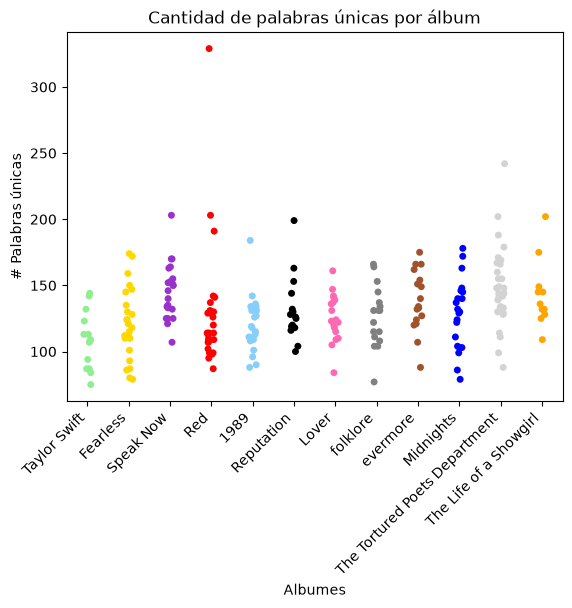

In [ ]:
sns.stripplot(data=data,x='Album',y='Número unico de palabras',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("# Palabras únicas")
plt.xlabel("Albumes")
plt.title("Cantidad de palabras únicas por álbum")
plt.show()

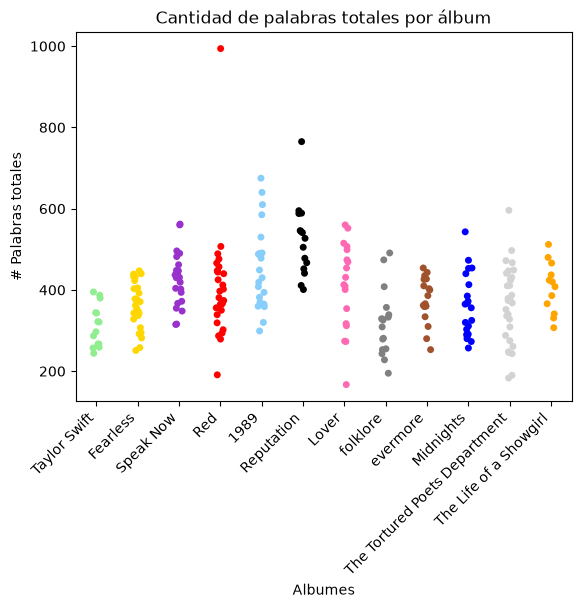

In [ ]:
sns.stripplot(data=data,x='Album',y='Palabras Totales',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("# Palabras totales")
plt.xlabel("Albumes")
plt.title("Cantidad de palabras totales por álbum")
plt.show()

In [ ]:
unique_words_album = data.groupby("Album")["Lyrics"].apply(lambda x: len(set(palabra for letra in x for palabra in re.findall(r'\b[a-zA-ZÀ-ÿ]+\b', str(letra).lower()))))
print("Cantidad de palabras únicas por álbum:")
print(unique_words_album)

Cantidad de palabras únicas por álbum:
Album
1989                             1029
Fearless                          977
Lover                             999
Midnights                        1212
Red                              1212
Reputation                        908
Speak Now                        1183
Taylor Swift                      639
The Life of a Showgirl            930
The Tortured Poets Department    1876
evermore                         1099
folklore                         1048
Name: Lyrics, dtype: int64


In [ ]:
sns.stripplot(data=data,x='Album',y='Duration (s)',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("Duración (s)")
plt.xlabel("Albumes")
plt.title("Duración de canciones por album")
plt.show()

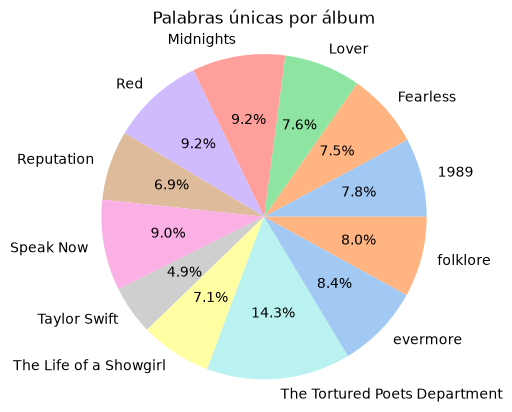

In [ ]:
plt.pie(unique_words_album,labels=unique_words_album.index,colors=sns.color_palette('pastel'),autopct='%1.1f%%',radius=1.1)
plt.title("Palabras únicas por álbum")
plt.show()

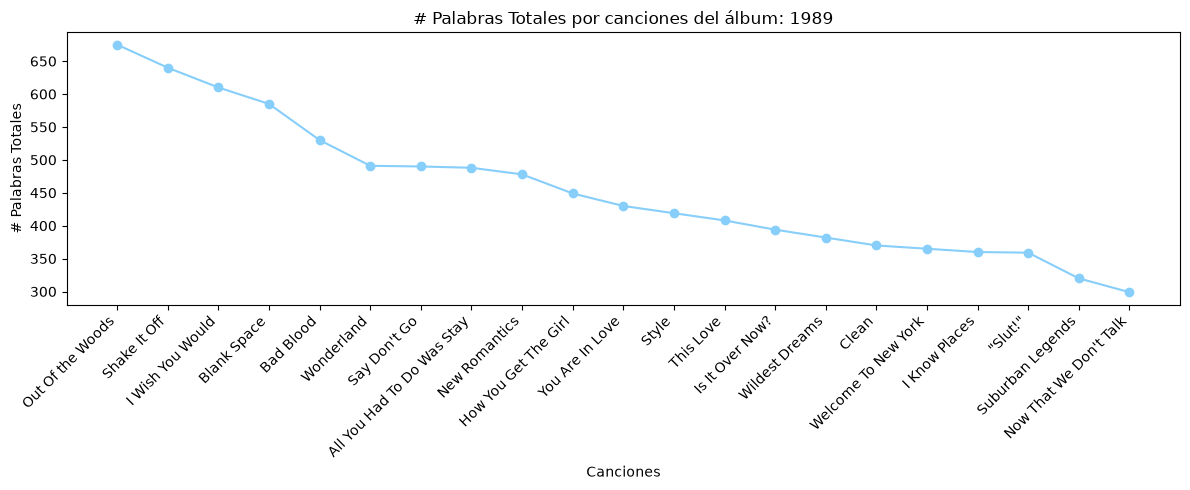

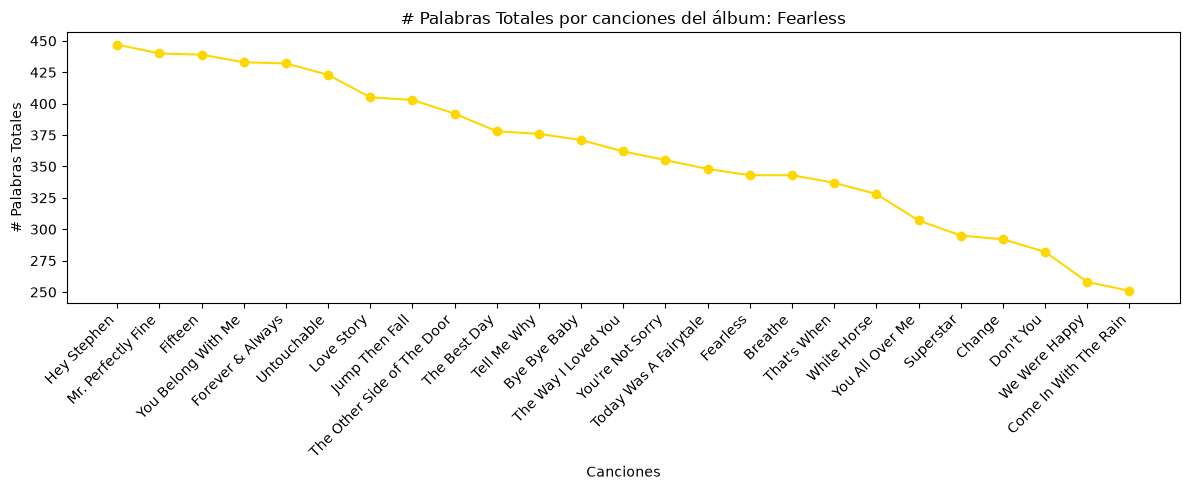

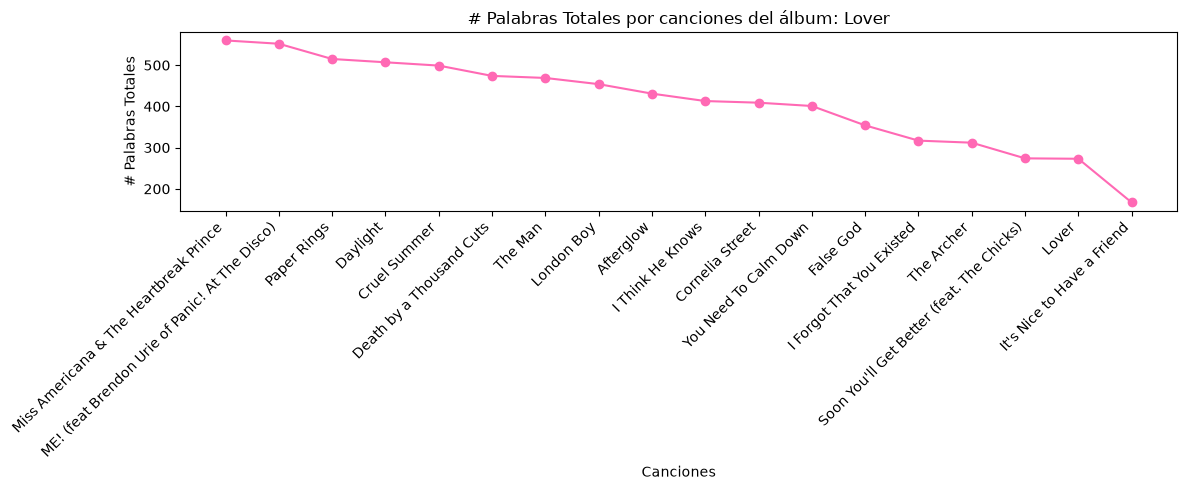

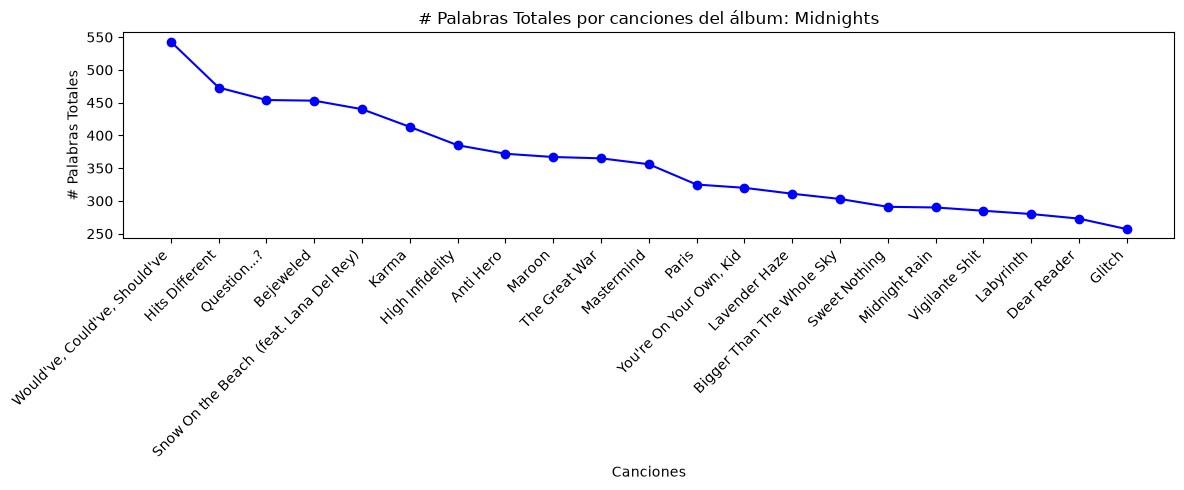

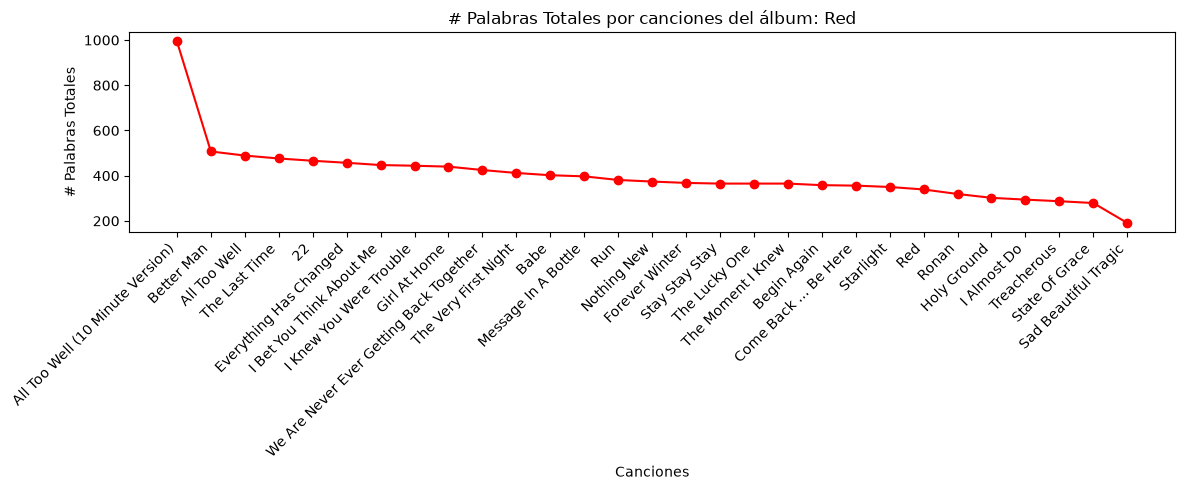

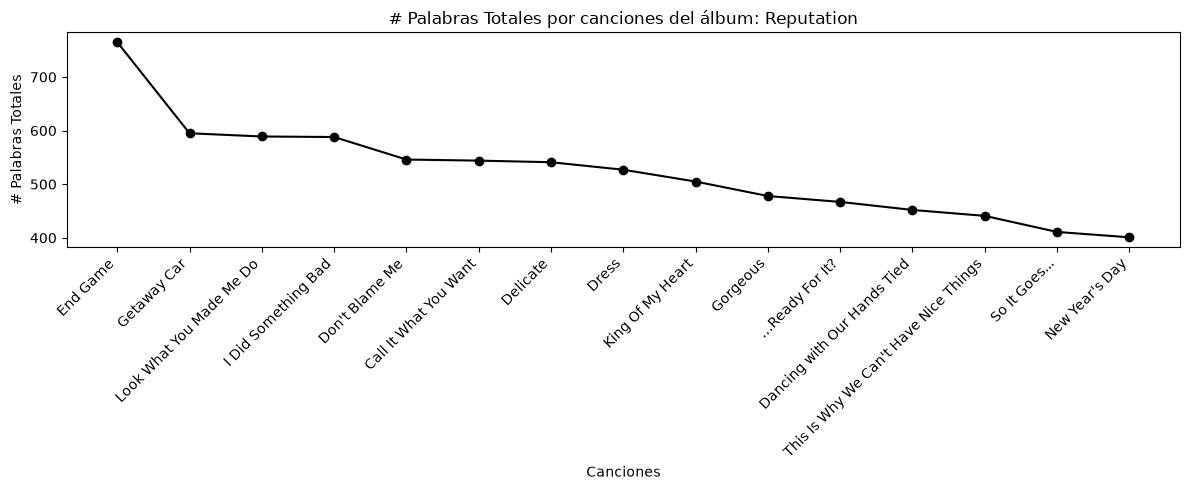

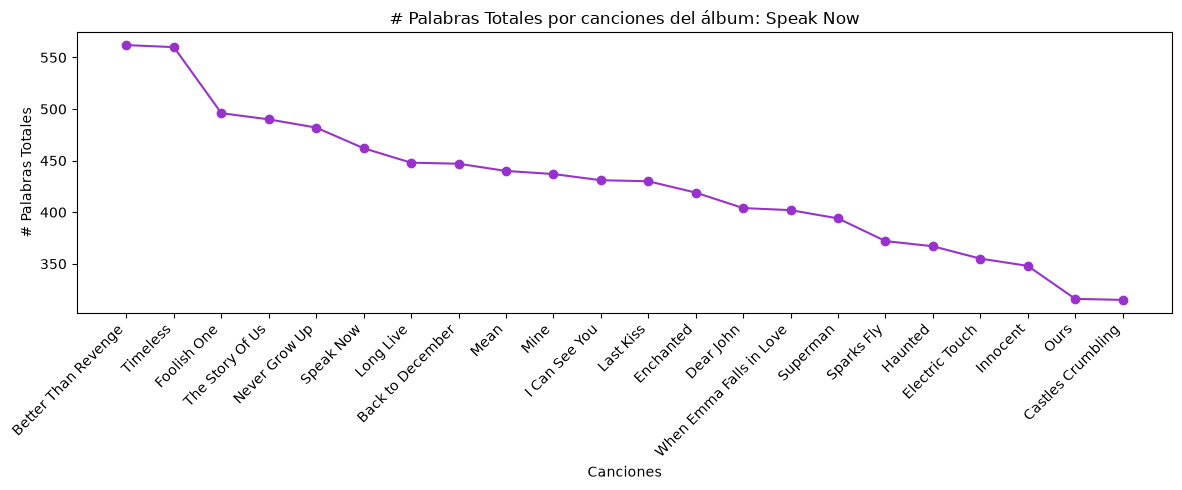

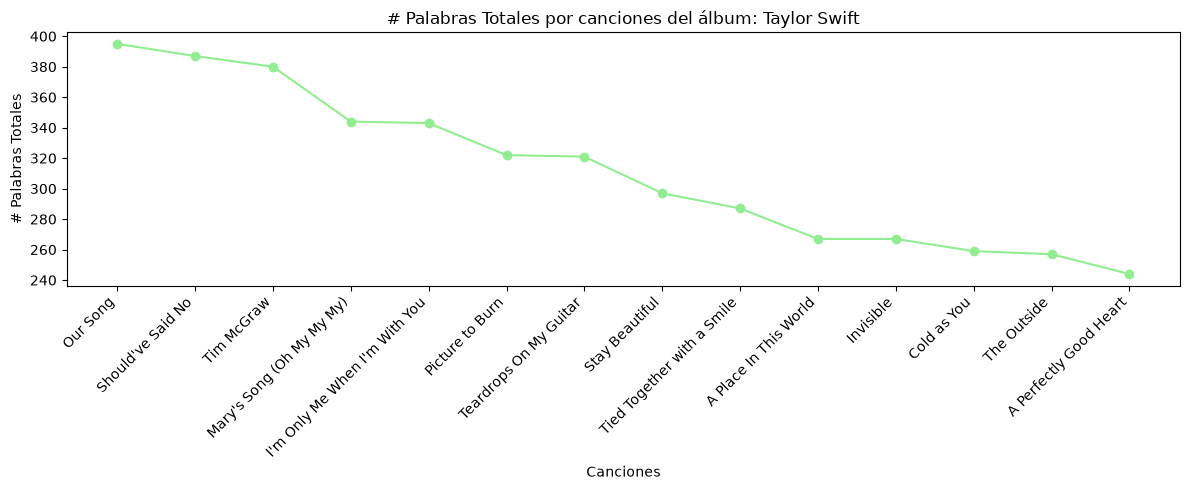

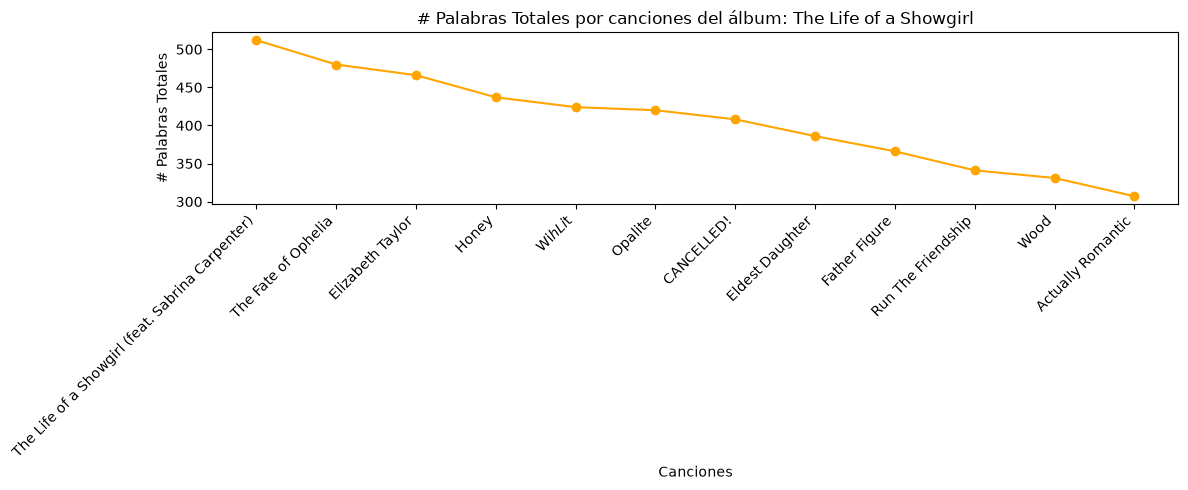

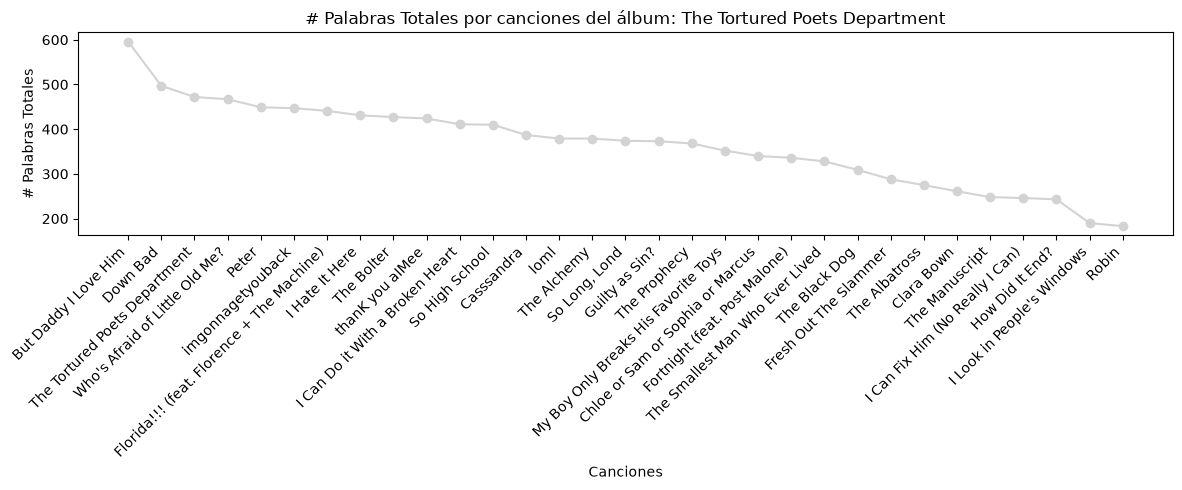

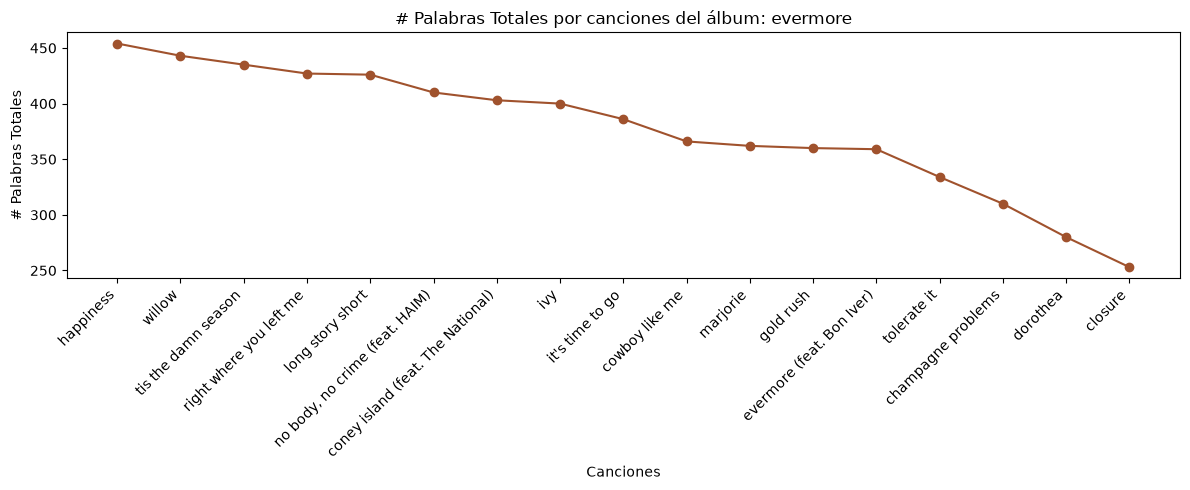

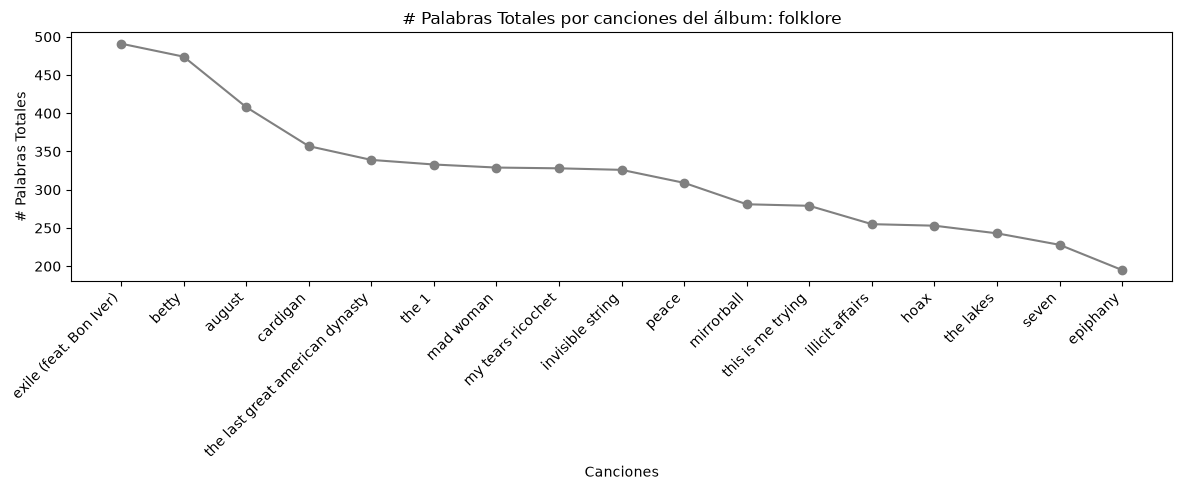

In [ ]:
sorted_column = data.sort_values(['Album', 'Palabras Totales'],ascending=[True, False])
album_colors = {'Taylor Swift': 'lightgreen','Fearless': 'gold','Speak Now': 'darkorchid','Red': 'red','1989': 'lightskyblue','Reputation': 'black','Lover': 'hotpink','folklore': 'grey','evermore': 'sienna','Midnights': 'blue','The Tortured Poets Department': 'lightgrey','The Life of a Showgirl': 'orange'}

for album, album_data in sorted_column.groupby('Album'):
    plt.figure(figsize=(12, 5))
    plt.plot(album_data['Song Name'],album_data['Palabras Totales'],marker='o',color=album_colors[album])
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Canciones")
    plt.ylabel("# Palabras Totales")
    plt.title(f"# Palabras Totales por canciones del álbum: {album}")
    plt.tight_layout()
    plt.show()

# NLP

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Tokenizer

In [ ]:
data = pd.read_excel("Taylor_Swift_Genius_Data.xlsx",header=0)
data['Album'] = data['Album'].astype(str)
data['Song Name'] = data['Song Name'].astype(str)
indices_to_drop = data[data['Lyrics'] == "-"].index
print(indices_to_drop)
data.drop(indices_to_drop, inplace=True)

data['CleanedLyrics'] = data['Lyrics'].str.lower().str.split()


Index([29, 81, 113, 202, 203], dtype='int64')


In [ ]:
data.head()

,Track Number,Album,Taylor's Version,Song Name,Duration (s),From The Vault,Lyrics,CleanedLyrics
0,10,Taylor Swift,No,Mary's Song (Oh My My My),213,NaN,She said I was seven and you were nine I looke...,"[she, said, i, was, seven, and, you, were, nin..."
1,14,Taylor Swift,No,A Perfectly Good Heart,220,NaN,Why would you wanna break A perfectly good hea...,"[why, would, you, wanna, break, a, perfectly, ..."
2,1,Taylor Swift,No,Tim McGraw,232,NaN,He said the way my blue eyes shined Put those ...,"[he, said, the, way, my, blue, eyes, shined, p..."
3,3,Taylor Swift,No,Teardrops On My Guitar,203,NaN,Drew looks at me I fake a smile so he won't se...,"[drew, looks, at, me, i, fake, a, smile, so, h..."
4,5,Taylor Swift,No,Cold as You,239,NaN,You have a way of coming easily to me And when...,"[you, have, a, way, of, coming, easily, to, me..."


### RoBERTA

In [ ]:
from transformers import pipeline

sentiment = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

text = data.loc[0, "Lyrics"]

result = sentiment(text)

print(result)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors: downloading bytes:           |  0.00B            

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[{'label': 'positive', 'score': 0.6423959732055664}]


In [ ]:
def analizar_cancion(texto, chunk_size=400):
    palabras = str(texto).split()

    chunks = [
        " ".join(palabras[i:i + chunk_size])
        for i in range(0, len(palabras), chunk_size)
    ]

    resultados = sentiment(chunks, truncation=True)

    scores = []

    for resultado in resultados:
        if resultado["label"] == "positive":
            scores.append(resultado["score"])
        elif resultado["label"] == "negative":
            scores.append(-resultado["score"])
        else:
            scores.append(0)

    return sum(scores) / len(scores)

data["RoBERTa Score"] = data["Lyrics"].apply(analizar_cancion)

RuntimeError: index 514 is out of bounds for dimension 1 with size 514

In [ ]:
from transformers import pipeline
import pandas as pd

sentiment = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

def analizar_cancion(texto, chunk_size=200):
    palabras = str(texto).split()

    chunks = [
        " ".join(palabras[i:i + chunk_size])
        for i in range(0, len(palabras), chunk_size)
    ]

    resultados = sentiment(
        chunks,
        truncation=True,
        max_length=512
    )

    scores = []

    for resultado in resultados:
        if resultado["label"] == "positive":
            scores.append(resultado["score"])
        elif resultado["label"] == "negative":
            scores.append(-resultado["score"])
        else:
            scores.append(0)

    return sum(scores) / len(scores)

data["RoBERTa Score"] = data["Lyrics"].apply(analizar_cancion)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


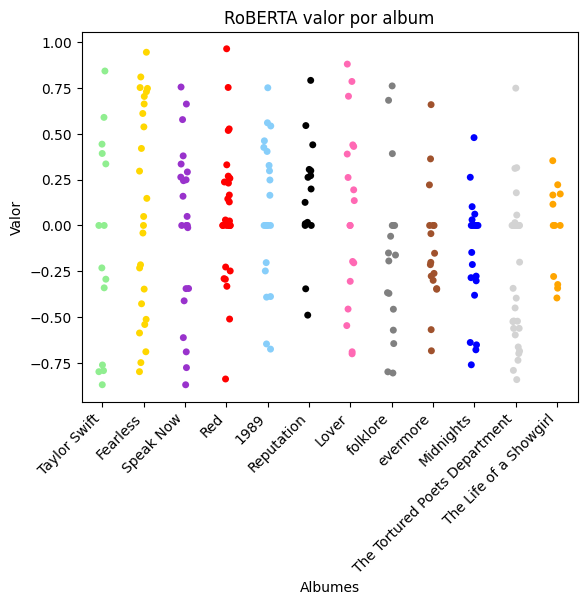

In [ ]:
sns.stripplot(data=data,x='Album',y='RoBERTa Score',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("Valor")
plt.xlabel("Albumes")
plt.title("RoBERTA valor por album")
plt.show()

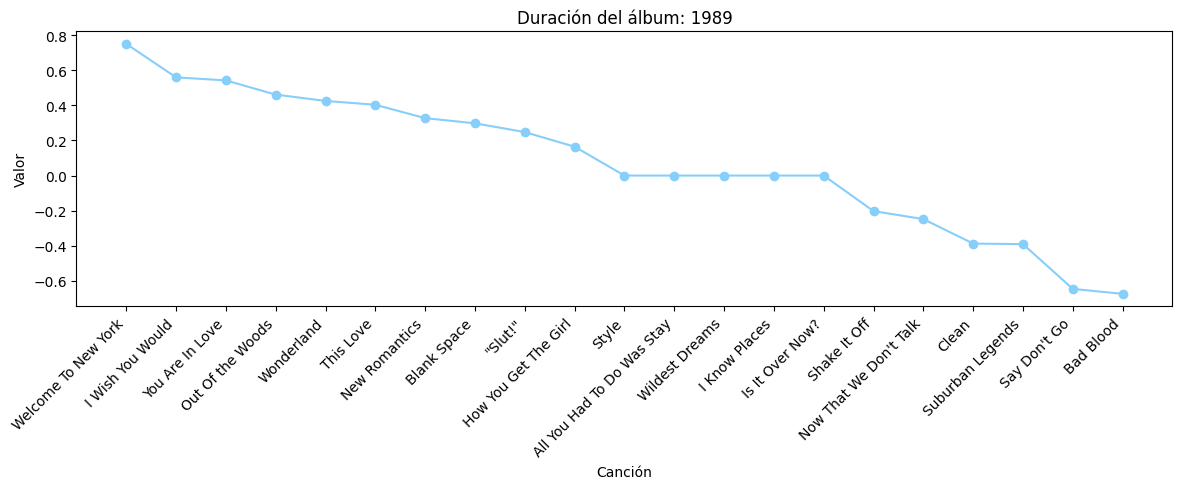

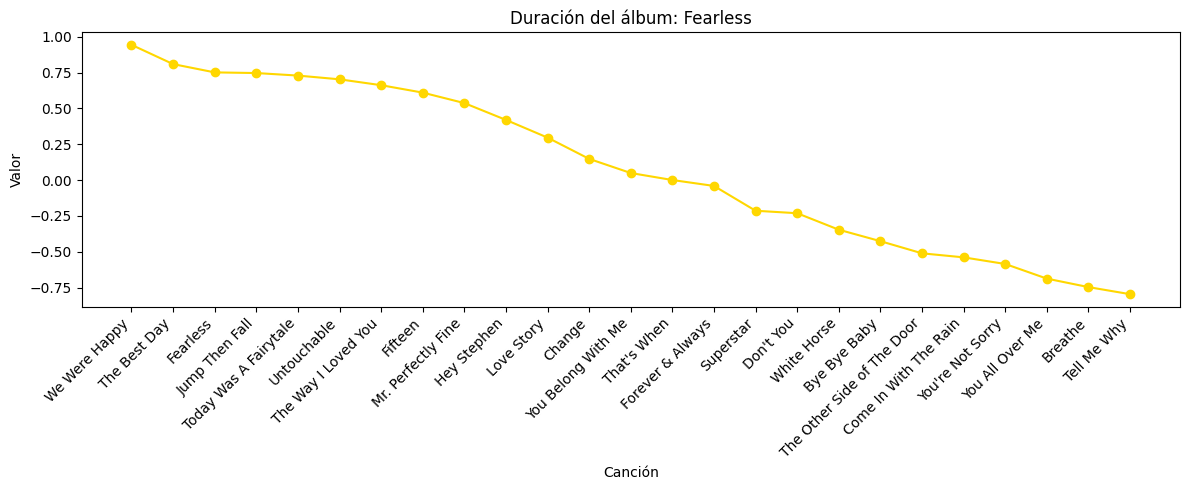

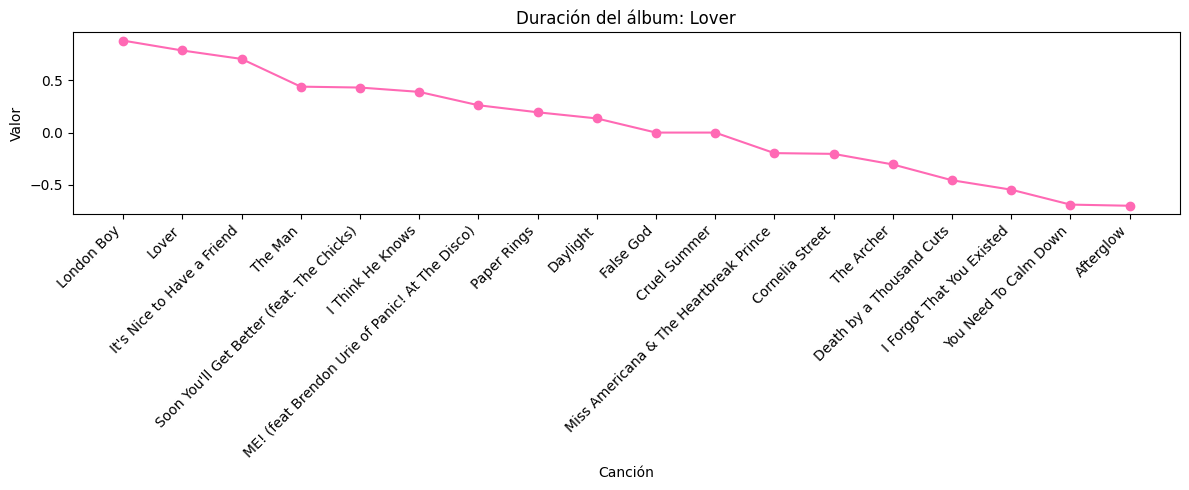

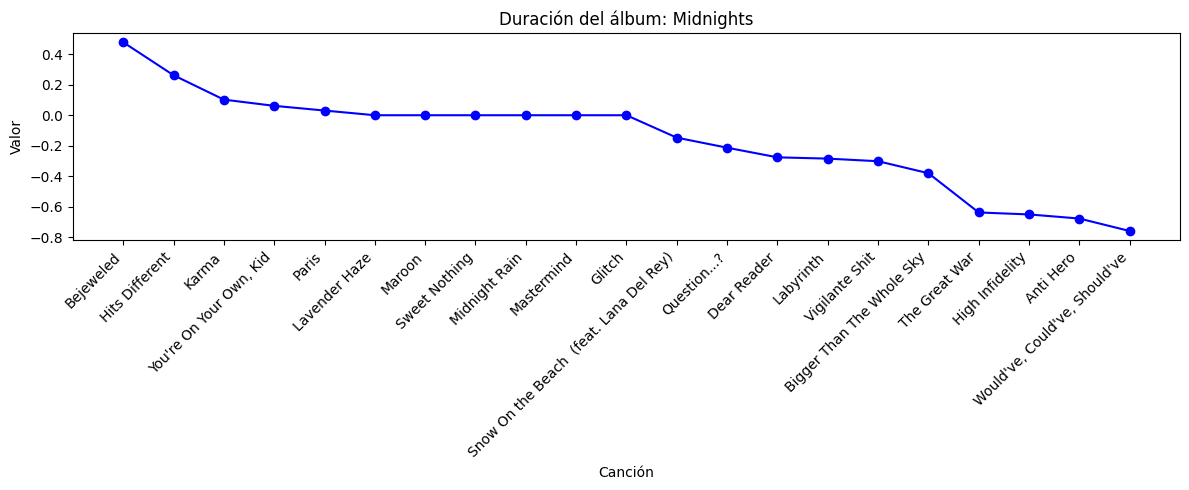

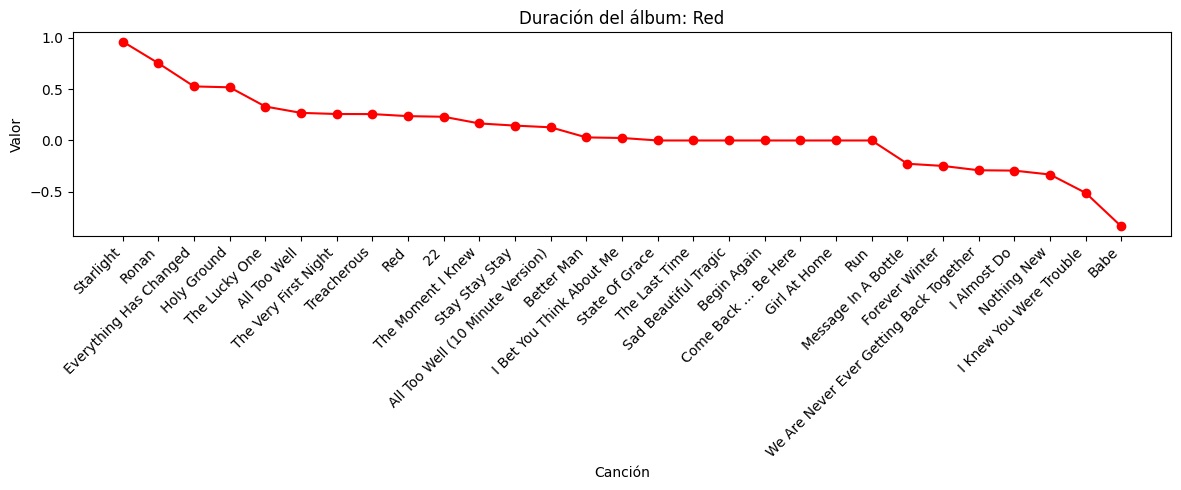

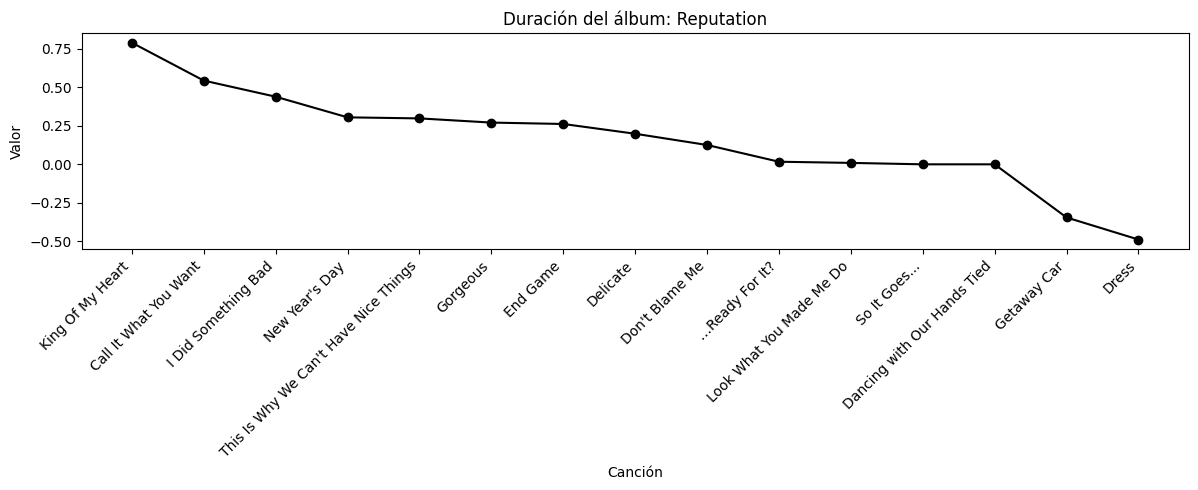

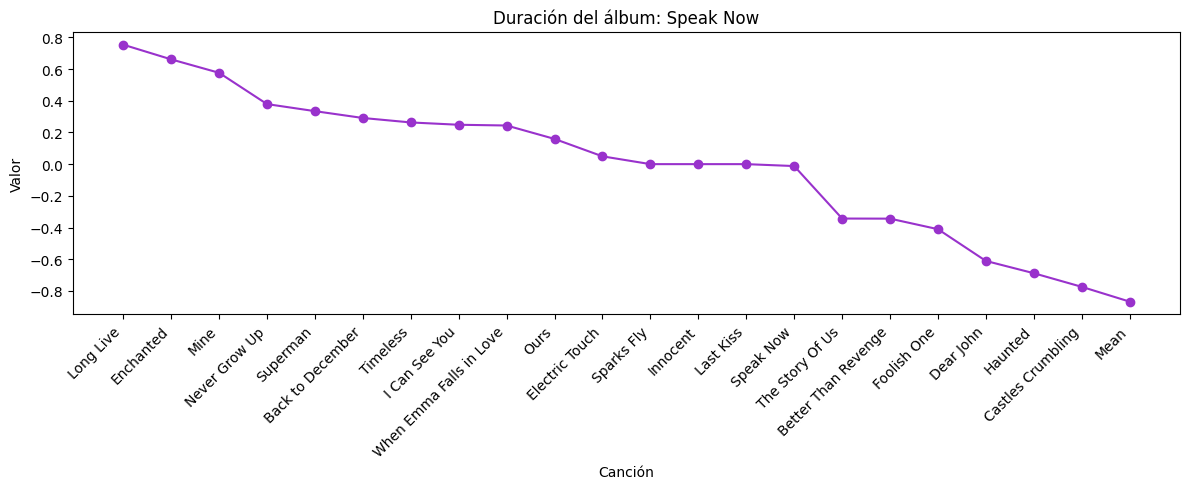

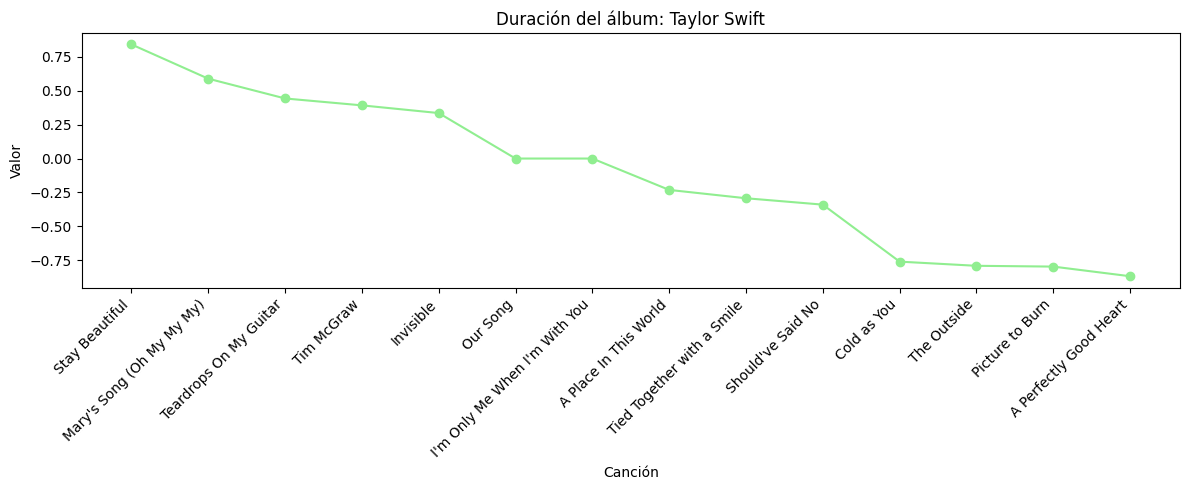

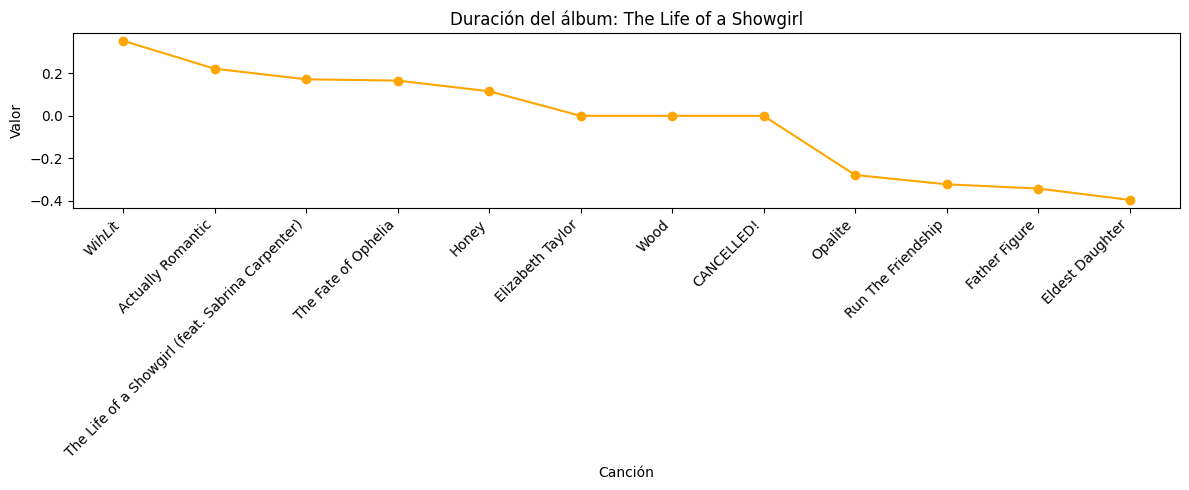

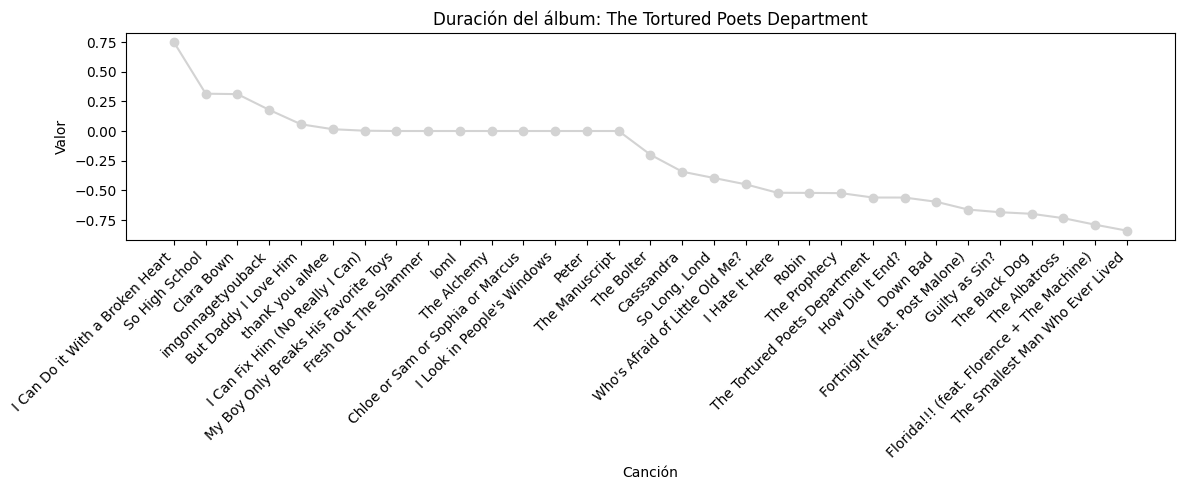

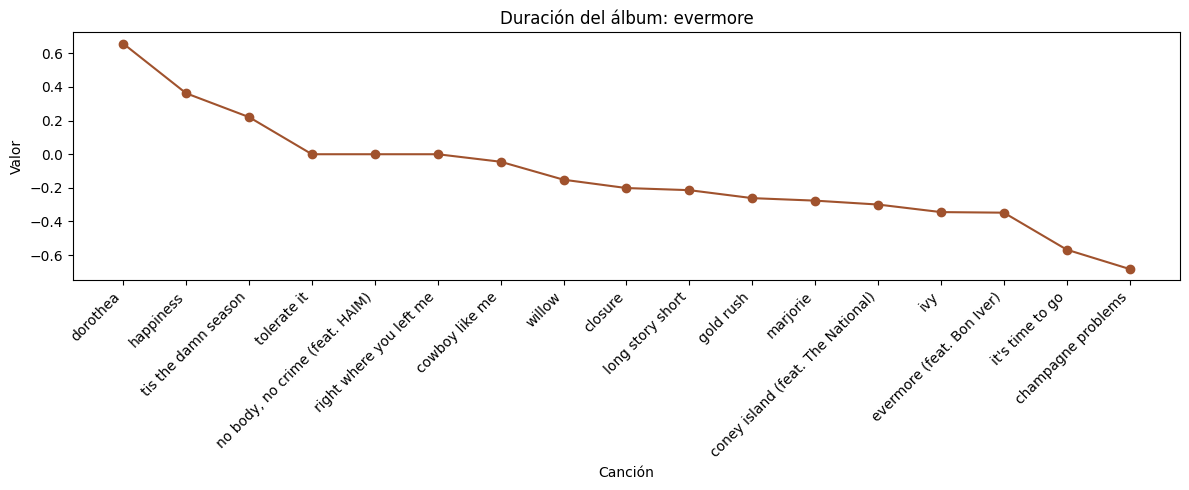

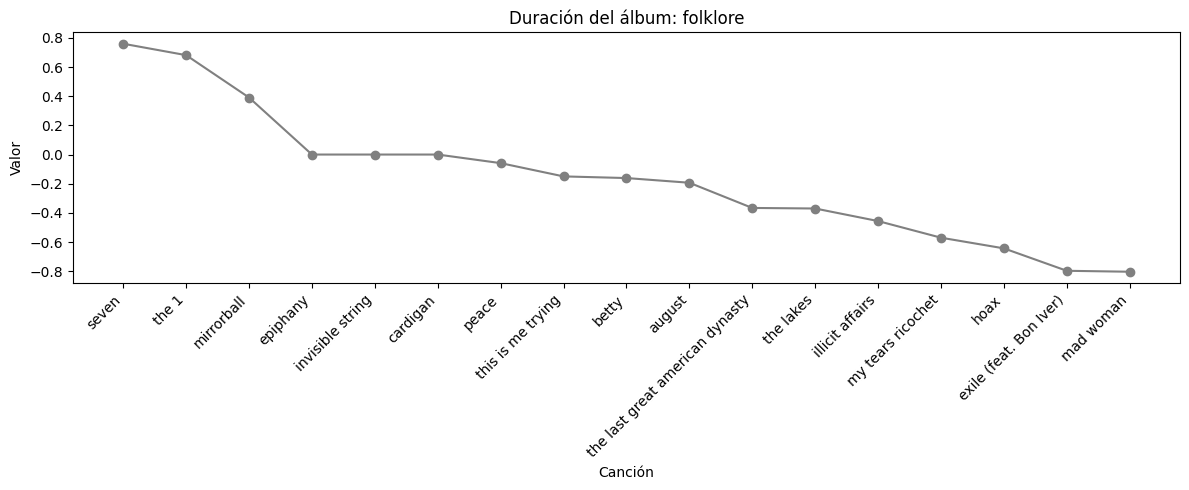

In [ ]:
sorted_column = data.sort_values(
    ['Album', 'RoBERTa Score'],
    ascending=[True, False]
)

album_colors = {
    'Taylor Swift': 'lightgreen',
    'Fearless': 'gold',
    'Speak Now': 'darkorchid',
    'Red': 'red',
    '1989': 'lightskyblue',
    'Reputation': 'black',
    'Lover': 'hotpink',
    'folklore': 'grey',
    'evermore': 'sienna',
    'Midnights': 'blue',
    'The Tortured Poets Department': 'lightgrey',
    'The Life of a Showgirl': 'orange'
}

for album, album_data in sorted_column.groupby('Album'):
    plt.figure(figsize=(12, 5))
    plt.plot(album_data['Song Name'],album_data['RoBERTa Score'],marker='o',color=album_colors[album])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Valor")
    plt.xlabel("Canción")
    plt.title(f"Duración del álbum: {album}")
    plt.tight_layout()
    plt.show()

### Blob

In [ ]:
from textblob import TextBlob

data["TextBlob Polarity"] = data["Lyrics"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)



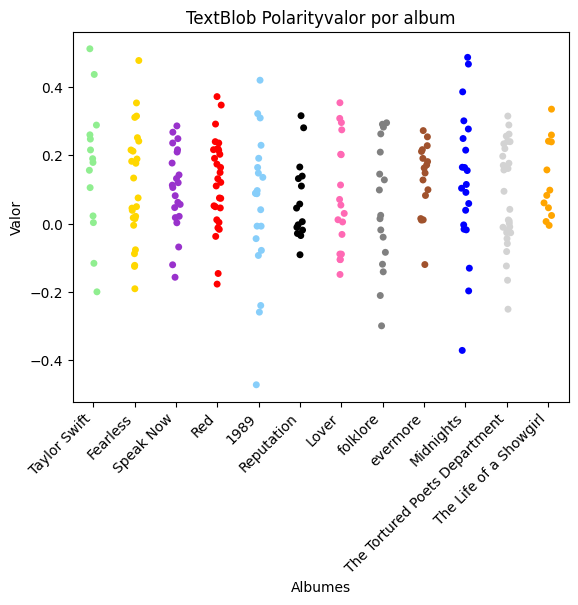

In [ ]:
sns.stripplot(data=data,x='Album',y='TextBlob Polarity',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("Valor")
plt.xlabel("Albumes")
plt.title("TextBlob Polarityvalor por album")
plt.show()

### VADER

In [ ]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
data["Negativo"] = data["Lyrics"].apply(
    lambda x: sia.polarity_scores(str(x))["neg"]
)

data["Neutral"] = data["Lyrics"].apply(
    lambda x: sia.polarity_scores(str(x))["neu"]
)

data["Positivo"] = data["Lyrics"].apply(
    lambda x: sia.polarity_scores(str(x))["pos"]
)

data["Compound"] = data["Lyrics"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

In [ ]:
max_sentiment = data["Compound"].idxmax()
min_sentiment = data["Compound"].idxmin()

print("Canción más positiva:")
print(data.loc[max_sentiment, ["Song Name", "Album", "Compound"]])

print("\nCanción más negativa:")
print(data.loc[min_sentiment, ["Song Name", "Album", "Compound"]])

Canción más positiva:
Song Name    This Love
Album             1989
Compound        0.9998
Name: 102, dtype: object

Canción más negativa:
Song Name    Shake It Off
Album                1989
Compound          -0.9998
Name: 97, dtype: object


In [ ]:
def clasificar_sentimiento(score):
    if score >= 0.20:
        return "Positivo"
    elif score <= -0.20:
        return "Negativo"
    else:
        return "Neutral"

data["Tipo de sentimiento"] = data["Compound"].apply(clasificar_sentimiento)

In [ ]:
print(data["Tipo de sentimiento"].value_counts())

Tipo de sentimiento
Positivo    167
Negativo     72
Neutral       3
Name: count, dtype: int64


Album
The Tortured Poets Department   -0.007448
evermore                         0.145894
1989                             0.198057
folklore                         0.208153
Midnights                        0.315067
Taylor Swift                     0.352664
Speak Now                        0.408200
The Life of a Showgirl           0.526667
Reputation                       0.611953
Lover                            0.633717
Fearless                         0.659892
Red                              0.769569
Name: Compound, dtype: float64


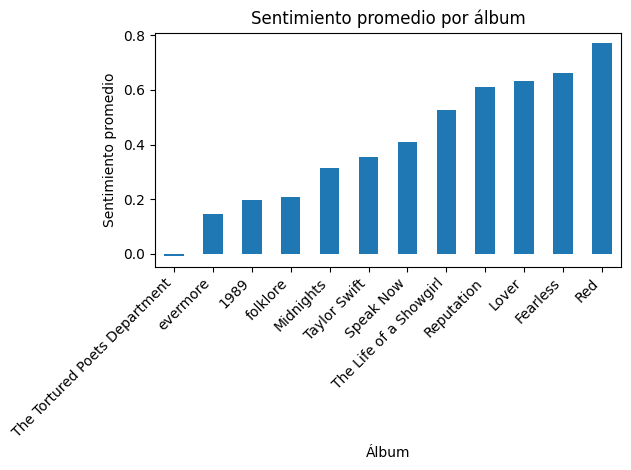

In [ ]:
sentimiento_album = data.groupby("Album")["Compound"].mean().sort_values()

print(sentimiento_album)
sentimiento_album.plot(kind="bar")

plt.xlabel("Álbum")
plt.ylabel("Sentimiento promedio")
plt.title("Sentimiento promedio por álbum")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Embeddings

In [ ]:
data.to_excel("Taylor-Swift-Values.xlsx")

### Sentence Bert

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")
lyrics = data["Lyrics"].tolist()
embeddings = model.encode(lyrics,show_progress_bar=True,normalize_embeddings=True)
embeddings.shape


similarity = cosine_similarity(embeddings)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:04<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embeddings_2d = reducer.fit_transform(embeddings)




/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


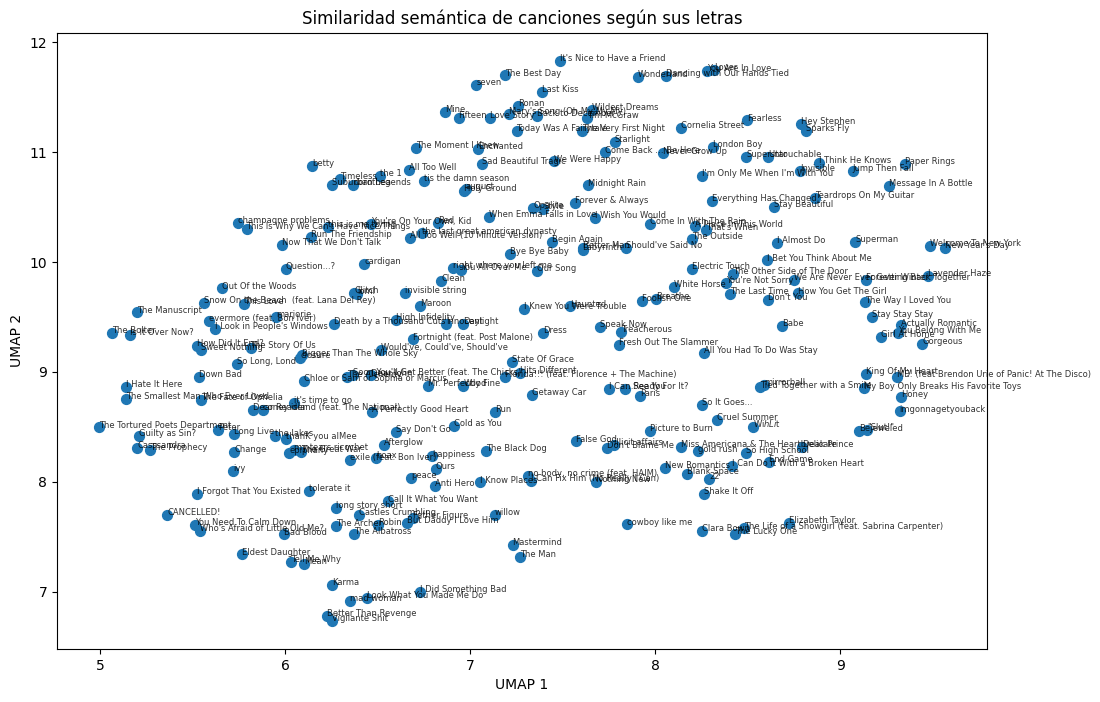

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0],embeddings_2d[:, 1],s=50)
for i, song in enumerate(data["Song Name"]):
    plt.annotate(
        song,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        fontsize=6,
        alpha=0.8
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Similaridad semántica de canciones según sus letras")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

data["Cluster"] = kmeans.fit_predict(embeddings)

### TF-ID

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

lyrics = data["Lyrics"]
vectorizer = TfidfVectorizer(stop_words="english",min_df=2,max_df=0.95)
X = vectorizer.fit_transform(lyrics)

X.shape

(242, 2030)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(X)
similarity

array([[1.        , 0.01499603, 0.10306805, ..., 0.06996724, 0.08261068,
        0.06082817],
       [0.01499603, 1.        , 0.00935464, ..., 0.08544377, 0.00768676,
        0.05924834],
       [0.10306805, 0.00935464, 1.        , ..., 0.02023472, 0.01781313,
        0.01838932],
       ...,
       [0.06996724, 0.08544377, 0.02023472, ..., 1.        , 0.03857518,
        0.03548307],
       [0.08261068, 0.00768676, 0.01781313, ..., 0.03857518, 1.        ,
        0.04365562],
       [0.06082817, 0.05924834, 0.01838932, ..., 0.03548307, 0.04365562,
        1.        ]])

In [ ]:
import numpy as np

i = 0

similar_songs = np.argsort(similarity[i])[::-1][1:6]

data.iloc[similar_songs][["Album", "Song Name"]]

,Album,Song Name
237,The Life of a Showgirl,Opalite
16,Fearless,Love Story
102,1989,This Love
234,The Tortured Poets Department,The Manuscript
144,Lover,You Need To Calm Down


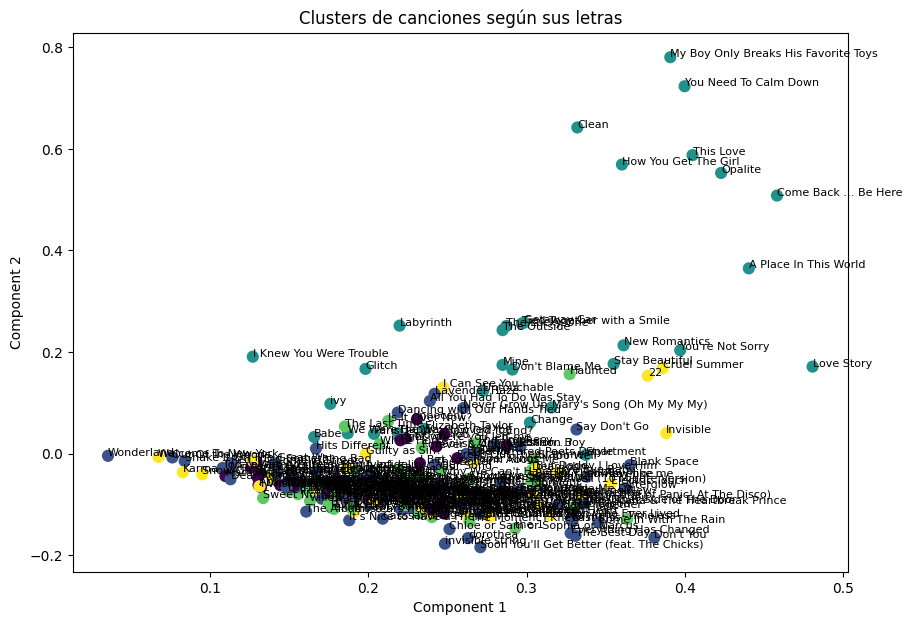

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5,random_state=42,n_init=10)

data["Cluster"] = kmeans.fit_predict(X)

from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=data["Cluster"],
    s=60
)

for i, song in enumerate(data["Song Name"]):
    plt.annotate(
        song,
        (X_2d[i, 0], X_2d[i, 1]),
        fontsize=8
    )

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Clusters de canciones según sus letras")
plt.show()